In [20]:
from pathlib import Path
from warnings import simplefilter

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

simplefilter("ignore")
plt.rcParams["figure.figsize"] = [15, 4]
sns.set_style('darkgrid')

In [4]:
path = Path('../../../Code in Zip/Time-Series-Analysis-with-Python-Cookbook-main/datasets/Ch8')
nyc_taxi = pd.read_csv(path / 'nyc_taxi.csv', index_col='timestamp', parse_dates=True)
nyc_taxi.index.freq = '30T'

<Axes: title={'center': 'NYC Taxi'}, xlabel='timestamp'>

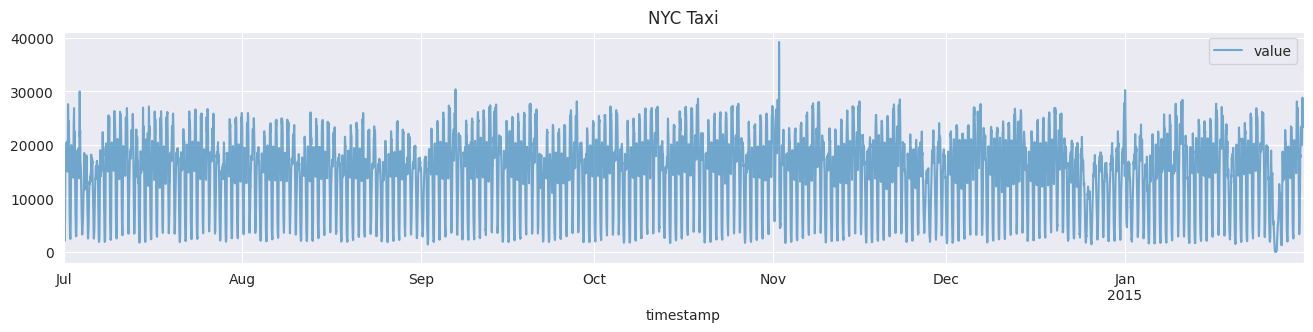

In [6]:
# store the known dates containing outliers, also known as ground truth labels
nyc_dates = [
    "2014-11-01",
    "2014-11-27",
    "2014-12-25",
    "2015-01-01",
    "2015-01-27"
]

# plot the time series data to gt an intuition
nyc_taxi.plot(title="NYC Taxi", alpha=.6)

In [34]:
# create plot_outliers function that will be used later in the recipes
def plot_outliers(outliers, df, method='KNN', halignment='right', valignment='bottom', labels=False):
    '''
    outliers: these are the known outliers dates like holidays
    df: dataframe to check and plot the outliers
    '''
    
    ax = df.plot(alpha=.6)

    if labels:
        for i in outliers['value'].items():
            plt.plot(i[0], i[1], 'rx')
            plt.text(i[0], i[1], f'{i[0].date()}', horizontalalignment=halignment, verticalalignment=valignment)
    else:
        df.loc[outliers.index].plot(ax=ax, style='rx')

    plt.title(f'NYC Taxi - {method}')
    plt.xlabel('date'); plt.ylabel('Number of passengers')
    plt.legend(['nyc taxi', 'outliers'])
    plt.show()

### Understanding outliers
**Domain knowledge** is essential in dealing with outliers. **Non-parametric** statistical methods that do not make assumptions on the underlying distribution. Statistical methods and test based on assumptions of the underlying distribution are called **Parametric methods**

-----------
### Resampling time series data
**Resampling** is changing the frequency or level of granularity of the data. Usually, you will have limited control over how the time series is generated in terms of frequency. For instance, the data can be generated and stored in small intervals, such as
milliseconds, minutes, or hours. In some cases, the data can be in larger intervals, such as
daily, weekly, or monthly.
**Downsampling** is when you can have daily data, but your analysis requires the data to be weekly, and thus you will need to resample.
**Upsampling** is like a situation that requires you to resample your data from daily to hourly.

In [8]:
nyc_taxi.head()

,value
timestamp,
2014-07-01 00:00:00,10844
2014-07-01 00:30:00,8127
2014-07-01 01:00:00,6210
2014-07-01 01:30:00,4656
2014-07-01 02:00:00,3820


In [9]:
df_downsampled = nyc_taxi.resample('D').mean()    # D for daily, 3B for business days
df_downsampled.head()

,value
timestamp,
2014-07-01,15540.979167
2014-07-02,15284.166667
2014-07-03,14794.625000
2014-07-04,11511.770833
2014-07-05,11572.291667


In [10]:
df_downsampled.index[0]

Timestamp('2014-07-01 00:00:00')

In [11]:
df_downsampled.index.freq

<Day>

In [12]:
df_downsampled.shape

(215, 1)

In [14]:
df_downsampled = nyc_taxi.resample('3D').sum()   # 3 day
df_downsampled.head()

,value
timestamp,
2014-07-01,2189749
2014-07-04,1658320
2014-07-07,2111672
2014-07-10,2335629
2014-07-13,2139711


In [15]:
df_downsampled.index.freq

<3 * Days>

In [16]:
# Lastly let's upsample the data from a 30-minute interval (frequency)
nyc_taxi.resample('15T').mean().head()

,value
timestamp,
2014-07-01 00:00:00,10844.0
2014-07-01 00:15:00,NaN
2014-07-01 00:30:00,8127.0
2014-07-01 00:45:00,NaN
2014-07-01 01:00:00,6210.0


**Note** 
***upsampling*** creates NaN rows. Unlike ***downsampling***, when upsampling,
you need to give instructions on how to fill the NaN rows.

In [17]:
# nyc_taxi.resample('15T').fillna('ffill')
nyc_taxi.resample('15T').ffill()

,value
timestamp,
2014-07-01 00:00:00,10844
2014-07-01 00:15:00,10844
2014-07-01 00:30:00,8127
2014-07-01 00:45:00,8127
2014-07-01 01:00:00,6210
...,...
2015-01-31 22:30:00,27309
2015-01-31 22:45:00,27309
2015-01-31 23:00:00,26591


In [18]:
nyc_taxi.resample('M').agg(['mean', 'min', 'max', 'median', 'sum'])

value                                
                    mean   min    max   median       sum
timestamp                                               
2014-07-31  14994.084677  1769  29985  16625.5  22311198
2014-08-31  14580.438844  1841  26062  16184.0  21695693
2014-09-30  15623.374306  1431  30373  17244.5  22497659
2014-10-31  16086.851478  1691  28626  17767.5  23937235
2014-11-30  15492.125000  1683  39197  17287.0  22308660
2014-12-31  14813.428763  1459  27804  16587.0  22042382
2015-01-31  14399.790995     8  30236  16061.0  21426889

### Detecting outliers using visualizations

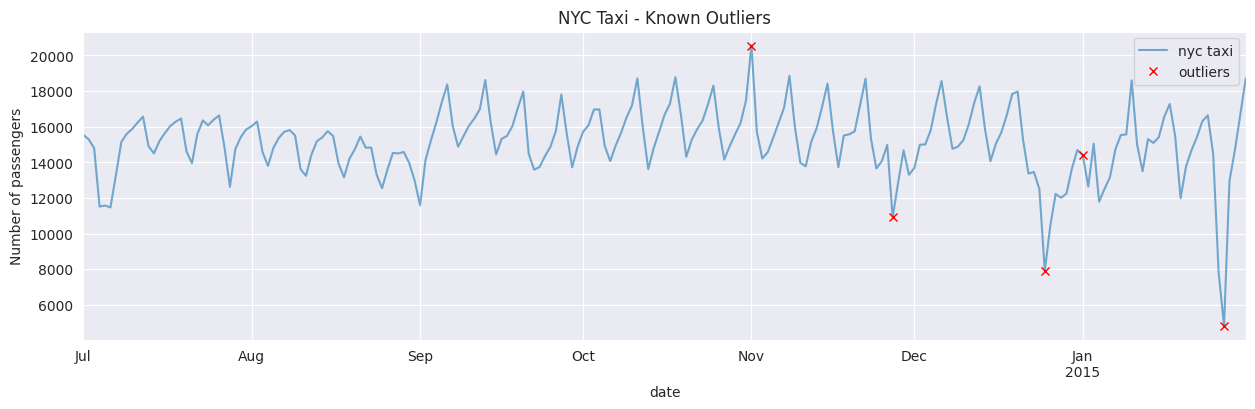

In [21]:
tx = nyc_taxi.resample('D').mean()

known_outliers = tx.loc[nyc_dates]
plot_outliers(known_outliers, tx, 'Known Outliers')

<Axes: ylabel='Count'>

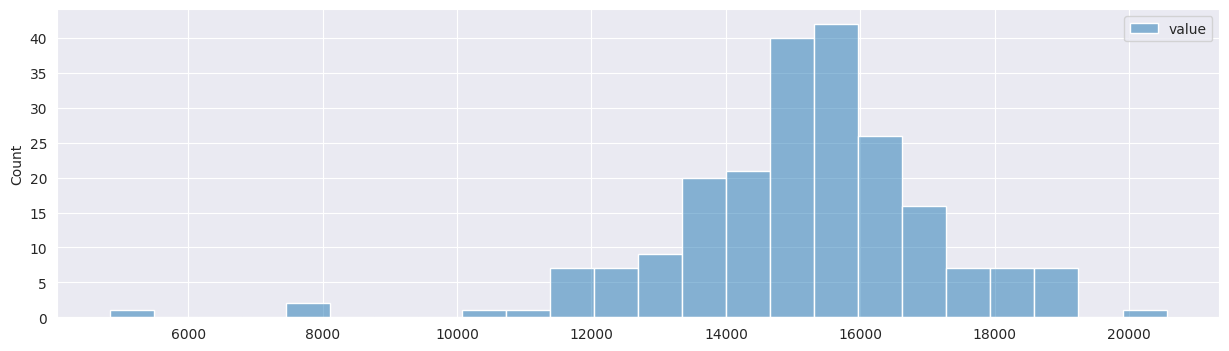

In [22]:
sns.histplot(tx)

The question you should ask yourself if these observations are outliers. The center of the histogram is closde to 15,000 daily average passengers after resampling. This should make you question whether the extreme value close to 20,000 is that extreme. Similarly, the observations with <= 8,000. Again, determining what is an outlier and what is not requires
domain knowledge and further analysis. There is no specific rule, and you will see
throughout this chapter that some of the generally accepted rules are arbitrary and
subjective. You should not jump to conclusions immediately.

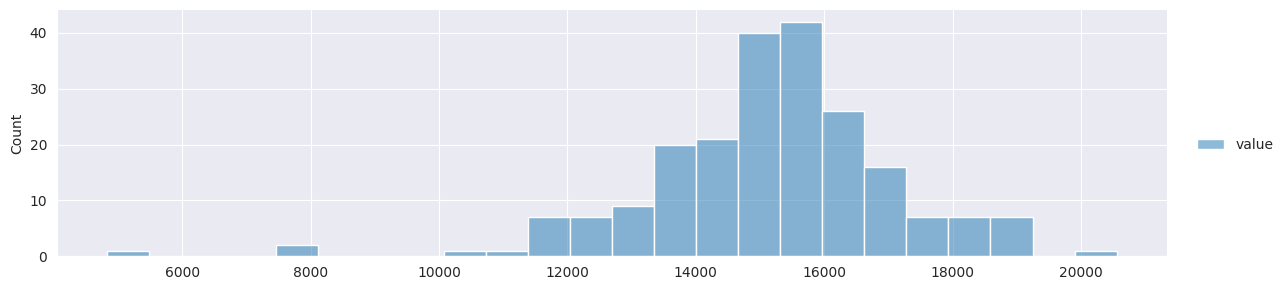

In [23]:
sns.displot(tx, kind='hist', height=3, aspect=4)

Box plot provides more information than histogram and can be a better choice for fro spotting outliers.

<Axes: ylabel='value'>

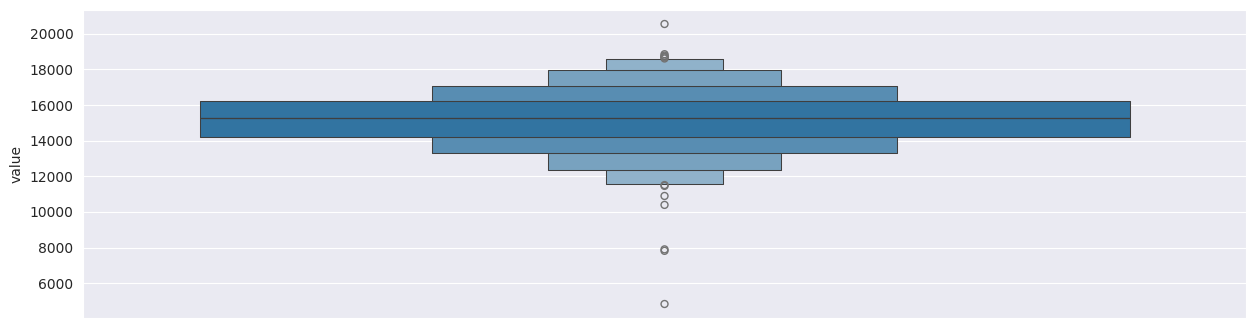

In [24]:
# sns.boxplot(tx['value'])
sns.boxenplot(tx['value'])

<Axes: >

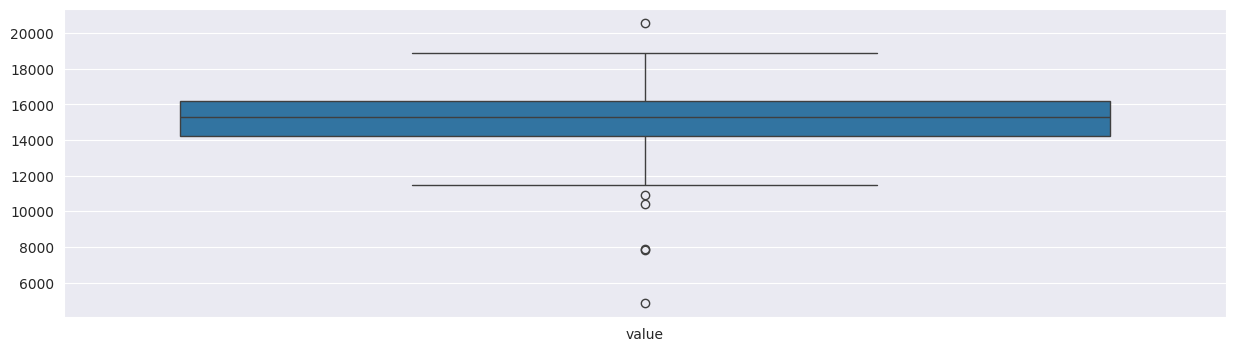

In [26]:
sns.boxplot([tx['value']])

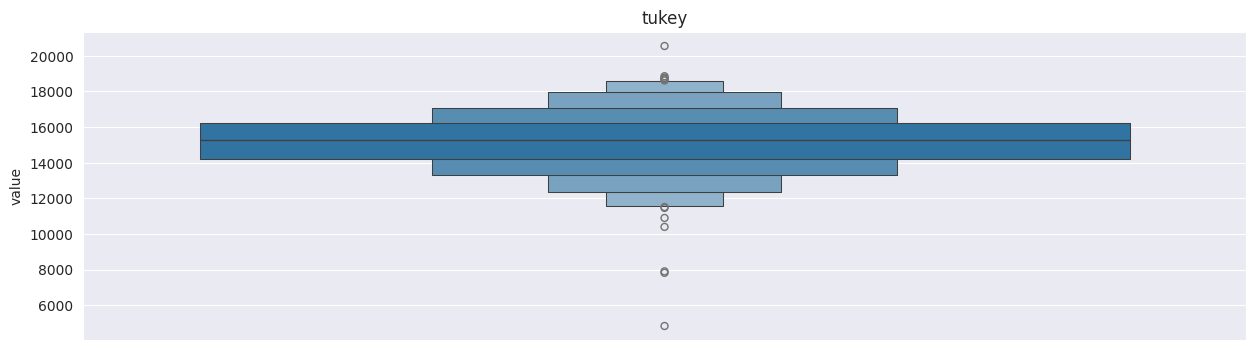

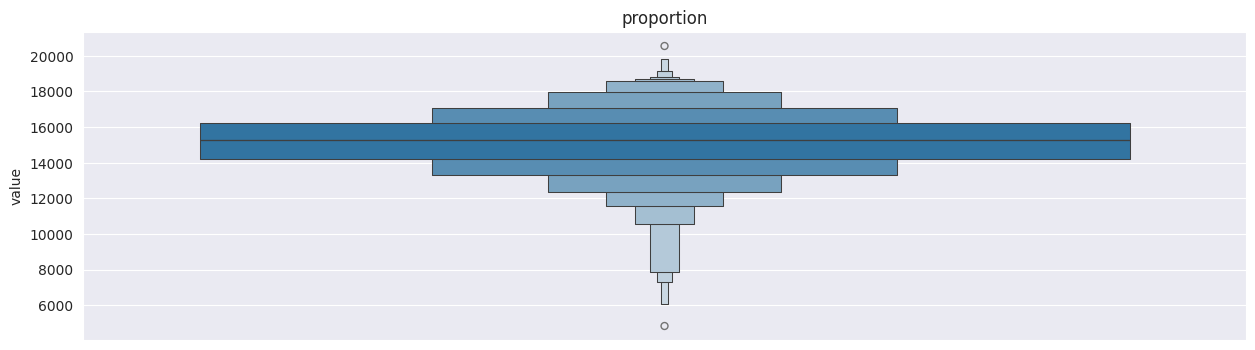

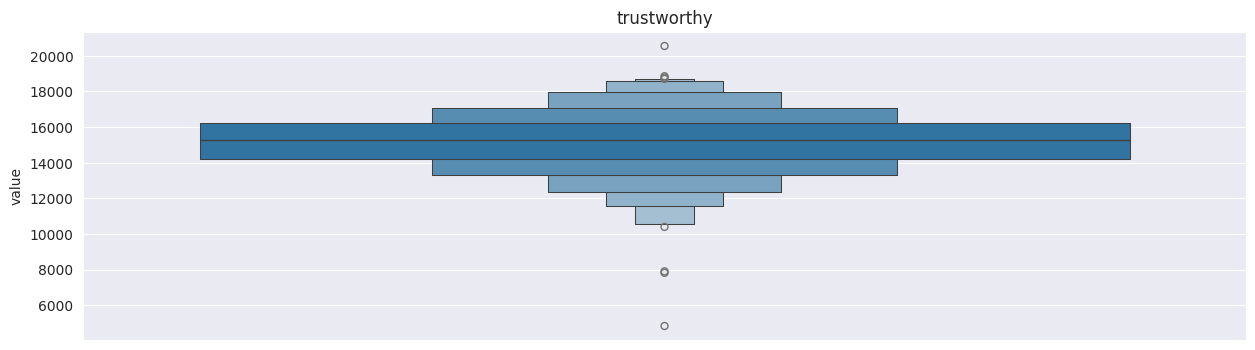

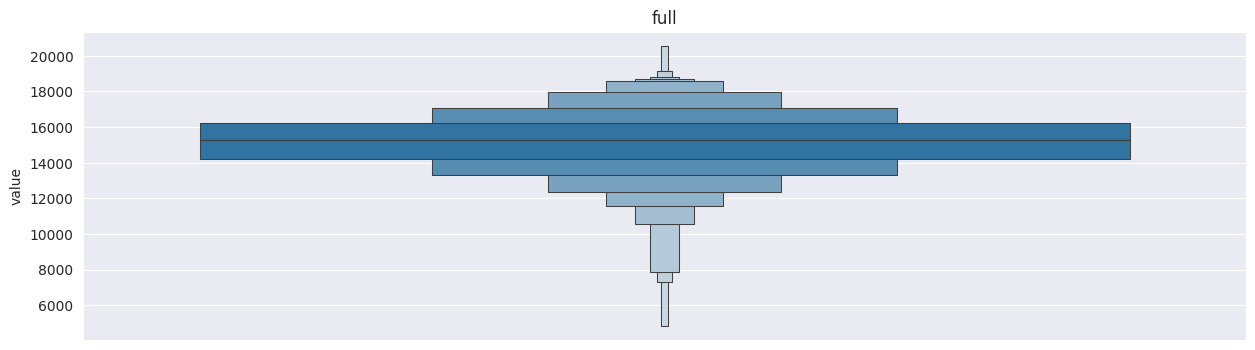

In [27]:
for k in ["tukey", "proportion", "trustworthy", "full"]:
    sns.boxenplot(tx['value'], k_depth=k)
    plt.title(k)
    plt.show()

<Axes: ylabel='value'>

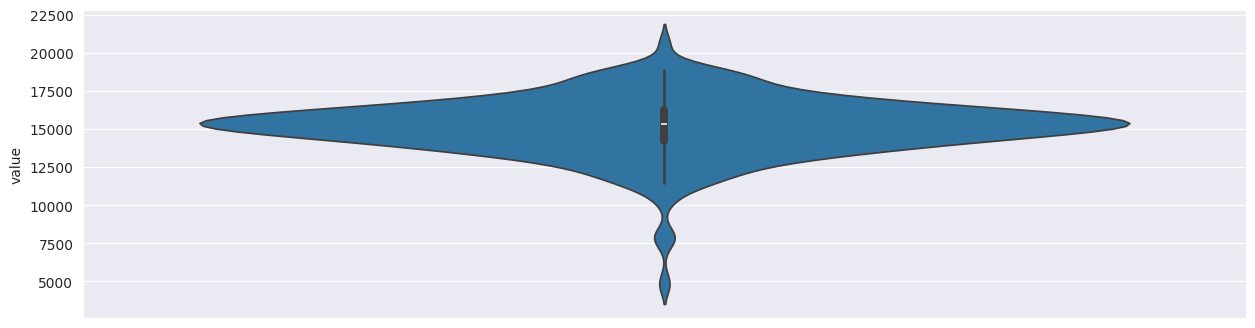

In [28]:
sns.violinplot(tx['value'])

<Axes: xlabel='y(t)', ylabel='y(t + 1)'>

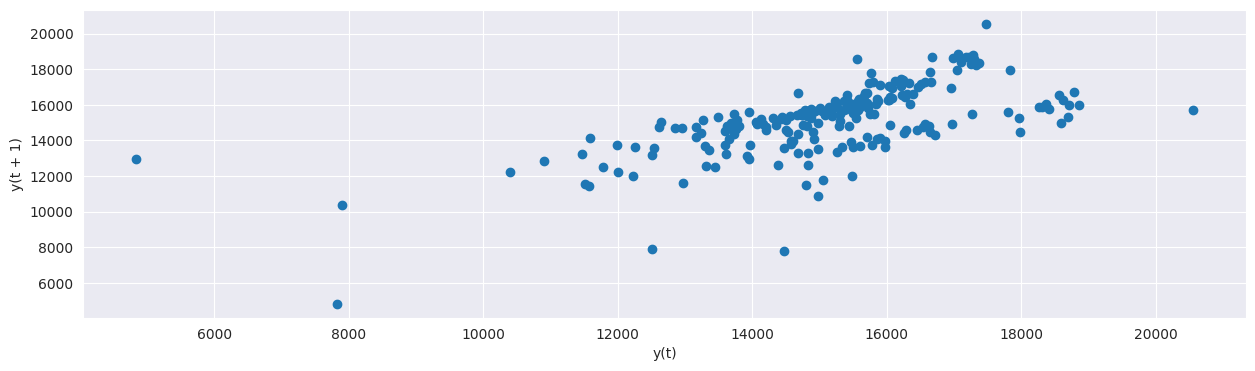

In [29]:
from pandas.plotting import lag_plot
lag_plot(tx)

Further, you can see some linear relationship between the passenger counts and its lagged  version (prior day) indicating the existence of an autocorrelation. Recall from basic statistics that correlation shows the relationship between two independent variables, so you can think of autocorrelation as a correlation of a variable at a time (t) and its prior version at a time (t-1). The labels for the x axis and the y axis in Figure 8.9 can be a bit confusing, with the y axis being labeled as y(t+1). Essentially it is saying the same thing we described earlier: the x axis represents prior values (the predictor) to its future self at t+1, which is what the y axis represents.

<Axes: >

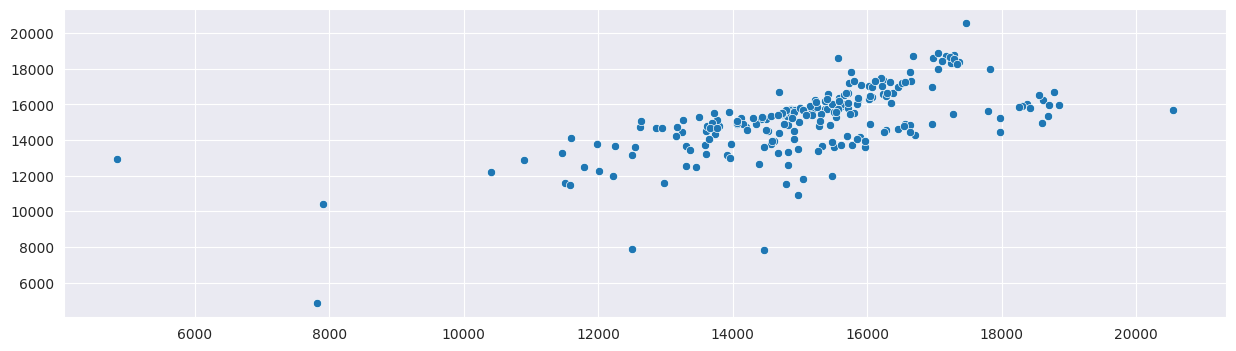

In [32]:
y = tx[1:].values.reshape(-1)
x = tx[:-1].values.reshape(-1)
sns.scatterplot(x=x, y=y)

### Detecting outliers using the Tukey method

In [33]:
percentiles = [0, .05, .1, .25, .5, .75, .90, .95, 1]
tx.describe(percentiles=percentiles)

,value
count,215.000000
mean,15137.569380
std,1937.391020
min,4834.541667
0%,4834.541667
5%,11998.181250
10%,13043.854167
25%,14205.197917
50%,15299.937500
75%,16209.427083


The lower and upper quantiles are known as ***Tukey's fences***

In [35]:
# This function selects all the outliers using interquartile range, 
# all this idea ia coming from box plots
def iqr_outliers(df):
    '''
    df: dataframe
    '''
    q1, q3 = np.percentile(df, [25, 75])
    iqr = q3 - q1
    lower_fence = q1 - (1.5 * iqr)
    upper_fence = q1 + (1.5 * iqr)

    return df[(df.value < lower_fence) | (df.value > upper_fence)]

In [36]:
outliers = iqr_outliers(tx)
outliers

,value
timestamp,
2014-09-05,17370.041667
2014-09-06,18369.041667
2014-09-13,18617.729167
2014-09-20,17974.083333
2014-09-27,17801.791667
2014-10-11,18706.416667
2014-10-17,17285.541667
2014-10-18,18778.958333
2014-10-24,17251.791667


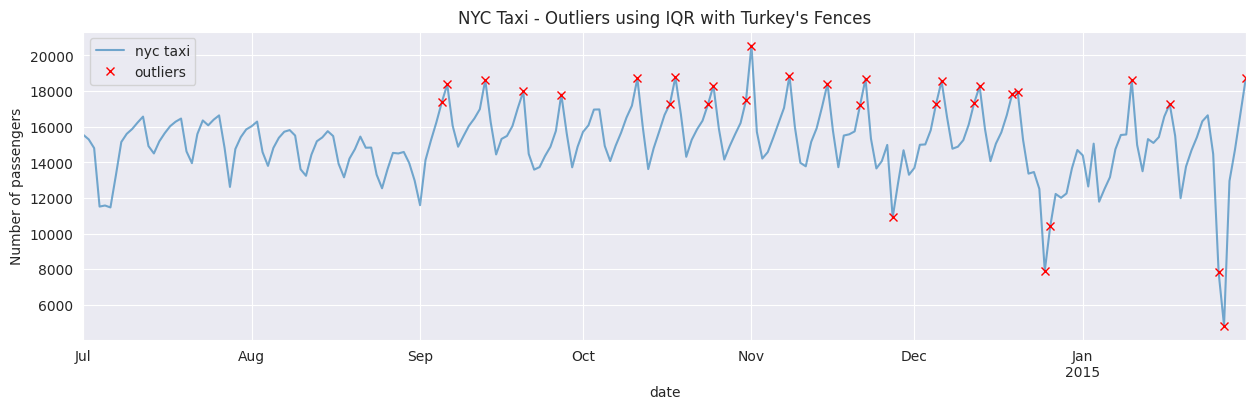

In [37]:
plot_outliers(outliers, tx, "Outliers using IQR with Turkey's Fences")

### Detecting outliers using a z-score

Where 𝑥 is a data point (an observation), mu ( 𝜇 ) is the mean of the dataset, and sigma ( 𝜎 ) is the standard deviation for the dataset.

Keep in mind that the z-score is a lossless transformation, which means you will not
lose information such as its distribution (shape of the data) or the relationship between
the observations. All that is changing is the units of measurement as they are being
scaled (standardized).

Once the data is transformed using the z-score, you can pick a threshold. So, any data
point above or below that threshold (in standard deviation) is considered an outlier. For
example, your threshold can be +3 and -3 standard deviations away from the mean. Any
point lower than -3 or higher than +3 standard deviation can be considered an outlier.
In other words, the further a point is from the mean, the higher the probability of it being
an outlier.

The z-score has one major shortcoming due to it being a parametric statistical method
based on assumptions. It assumes a Gaussian (normal) distribution. So, suppose the data
is not normal. In that case, you will need to use a modified version of the z-score, which is
discussed in the following recipe, Detecting outliers using a modified z-score.

array([[<Axes: title={'center': 'value'}>,
        <Axes: title={'center': 'zscore'}>]], dtype=object)

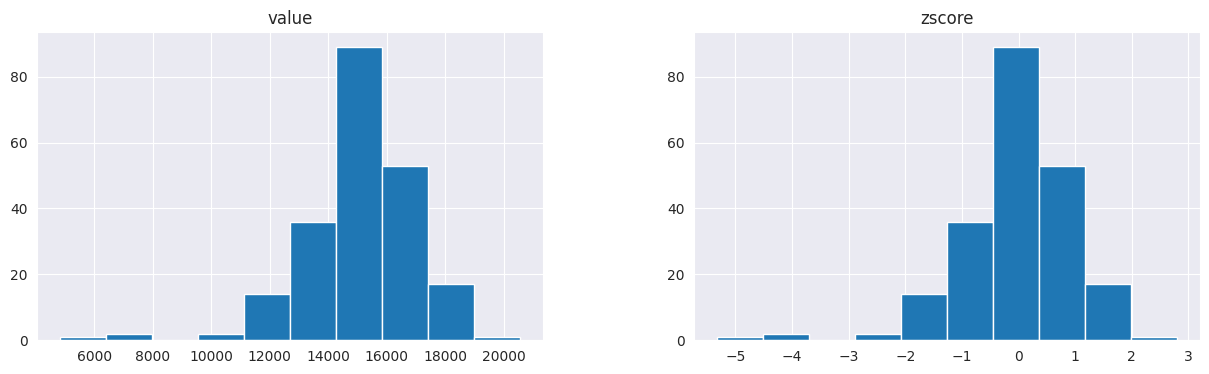

In [38]:
def z_score(df, degree=3):
    data = df.copy()
    data['zscore'] = (data - data.mean()) / data.std()
    outliers = data[(data['zscore'] <= -degree) | (data['zscore'] >= degree)]

    return outliers['value'], data

threshold = 2.5
outliers, transformed_data = z_score(tx, threshold)

transformed_data.hist()

Notice how the shape of the data did not change, hence why the z-score is called
a lossless transformation. The only difference between the two is the scale (units).

In [39]:
print(outliers)

timestamp
2014-11-01    20553.500000
2014-12-25     7902.125000
2015-01-26     7818.979167
2015-01-27     4834.541667
Name: value, dtype: float64


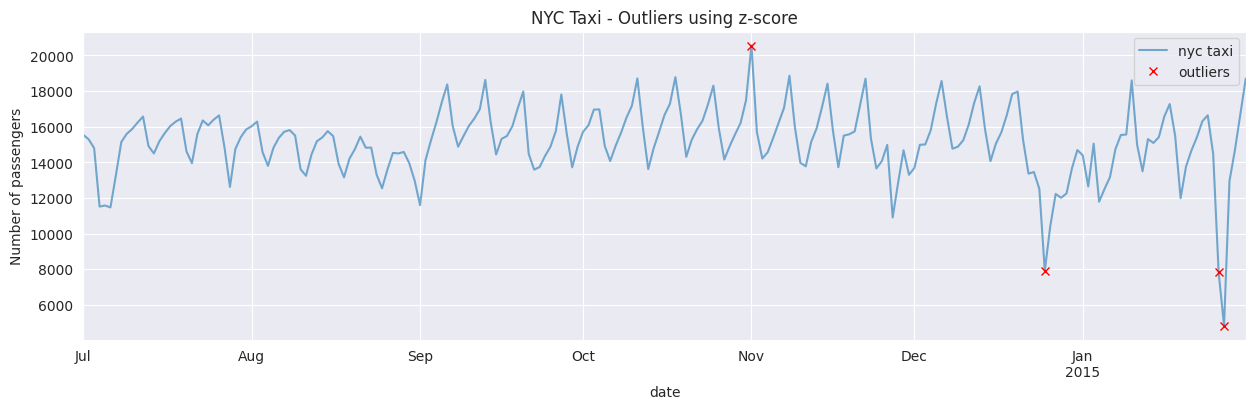

In [40]:
plot_outliers(outliers, tx, "Outliers using z-score")

In [41]:
def plot_zscores(df, degree=3):
    n = len(df)
    
    plt.figure(figsize=(8,8))
    plt.plot(df, 'k^')
    plt.plot([0,n], [degree,degree],'r--')
    plt.plot([0,n],[-degree, -degree], 'r--')
    plt.show()

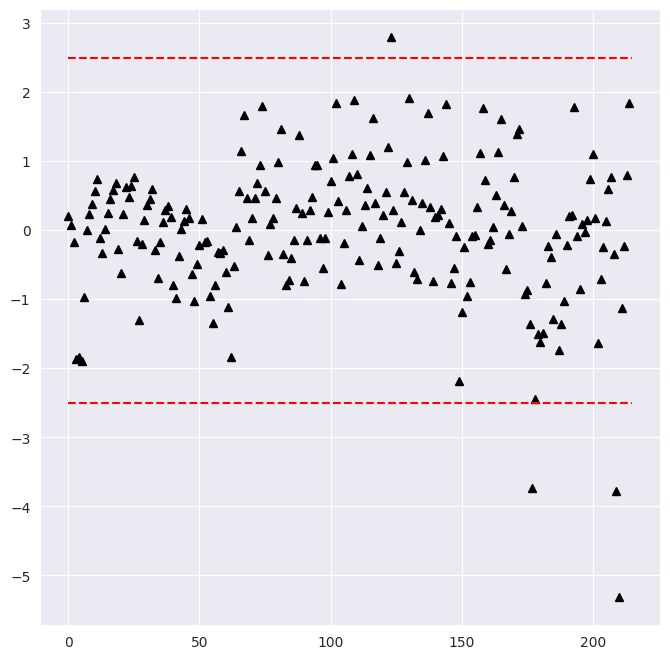

In [44]:
df = transformed_data['zscore'].values
plot_zscores(df, degree=2.5)

The z-score method is a very simple and interpretable method. The z-scores are interpreted as standard deviation units away from the mean, which is the center of the distribution. Since we are subtracting the mean from all observations, we are essentially mean-centering the data. We also divide by the standard deviation to standardize the data.

Once the data is standardized, it became easy to just use the standard deviation threshold. If the data was not standardized, it may have been challenging to determine the threshold based on daily passengers.

----------
The z-score is a parametric method and assumes the data comes from a Gaussian (normal) distribution. There are several tests available in the statsmodels library to test if the data is normally distributed. One of these tests is the Kolmogorov-Smirnov test. The null hypothesis is that the data comes from a normal distribution. The test returns the test
statistics and a p-value; if the p-value is less than 0.05, you can reject the null hypothesis
(data is not normally distributed). Otherwise, you would fail to reject the null hypothesis
(data is normally distributed).

In [51]:
from statsmodels.stats.diagnostic import kstest_normal

def test_normal(df):
    t_test, p_value = kstest_normal(df)
    if p_value < 0.05:
        print(f"P-value is {p_value} <= 0.05. We therefore, reject null hypothesis. Data is not normal")
    else:
        print(f"P-value is {np.round(p_value, .3)} >= 0.05. Therefore, we fail to reject null hypothesis. Data is normal")

In [52]:
test_normal(tx)

P-value is 0.0009999999999998899 <= 0.05. We therefore, reject null hypothesis. Data is not normal


### Detecting outliers using a modified z-score

In the Detecting outliers using a z-score recipe, you experienced how simple and
intuitive the method is. But it has one major drawback: it assumes your data is
normally distributed.

But, what if your data is not normally distributed? Luckily, there is a modified version
of the z-score to work with non-normal data. The main difference between the regular
z-score and the modified z-score is that we replace the mean with the median:

𝑀odified 𝑍 = 0.6745(𝑥𝑖 − 𝑥̃)/MAD

Where 𝑥𝑥̃ (tilde x) is the median of the dataset, and MAD is the median absolute deviation
of the dataset:

MAD = median(𝑎(𝑥𝑖 − 𝑥̃))

The 0.6745 value is the standard deviation unit that corresponds to the 75th percentile
(Q3) in a Gaussian distribution and is used as a normalization factor. In other words, it
is used to approximate the standard deviation. This way, the units you obtain from this
method are measured in standard deviation, similar to how you would interpret the
regular z-score.

In [53]:
import scipy.stats as stats
stats.norm.ppf(0.75)         # normalization factor used in the formula

np.float64(0.6744897501960817)

Lastly, the modified z-score is sometimes referred to as the ***robust z-score***.

In [57]:
def modified_z_score(df, degree=3):
    data = df.copy()
    s = stats.norm.ppf(0.75)
    numerator = s*(data - data.median())
    MAD = np.abs(data - data.median()).median()
    data['modified_zscore'] = numerator / MAD
    outliers = data[(data['modified_zscore'] > degree) | (data['modified_zscore'] < -degree)]

    return outliers['value'], data

array([[<Axes: title={'center': 'value'}>,
        <Axes: title={'center': 'modified_zscore'}>]], dtype=object)

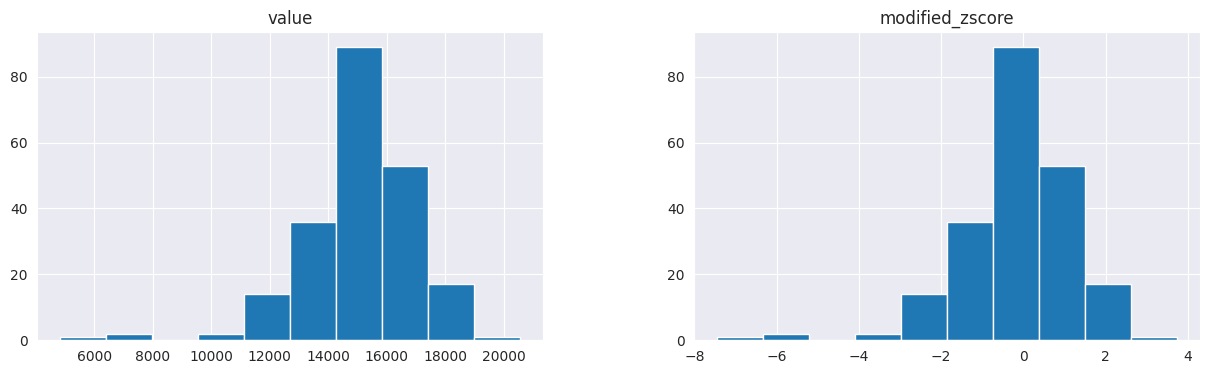

In [58]:
threshold = 3
outliers, transformed_data = modified_z_score(tx, threshold)

transformed_data.hist()

In [59]:
print(outliers)

timestamp
2014-11-01    20553.500000
2014-11-27    10899.666667
2014-12-25     7902.125000
2014-12-26    10397.958333
2015-01-26     7818.979167
2015-01-27     4834.541667
Name: value, dtype: float64


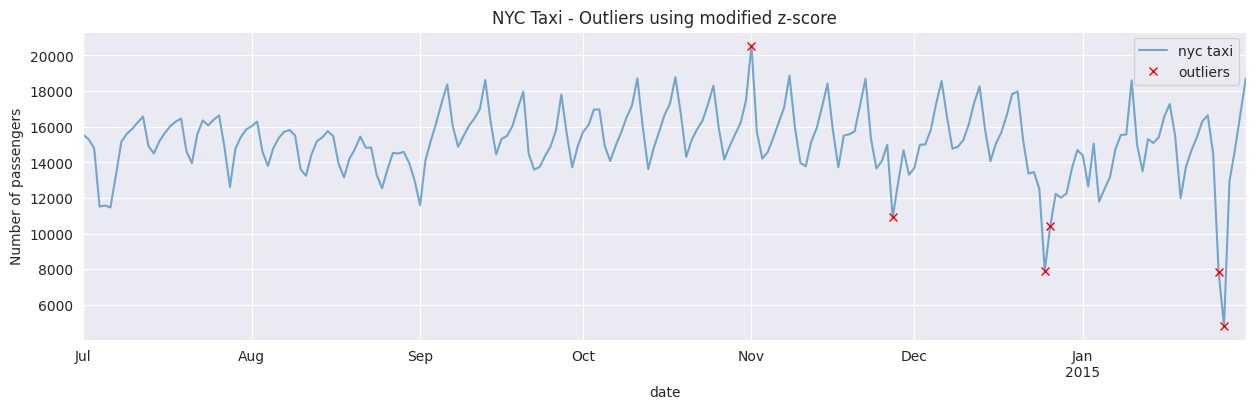

In [60]:
plot_outliers(outliers, tx, "Outliers using modified z-score")

In [61]:
def plot_modified_zscore(df, degree=3):
    n = len(df)

    plt.figure(figsize=(8,8))
    plt.plot(df, 'k^')
    plt.plot([0,n],[degree,degree],'r--')
    plt.plot([0,n],[-degree,-degree],'r--')
    plt.show()

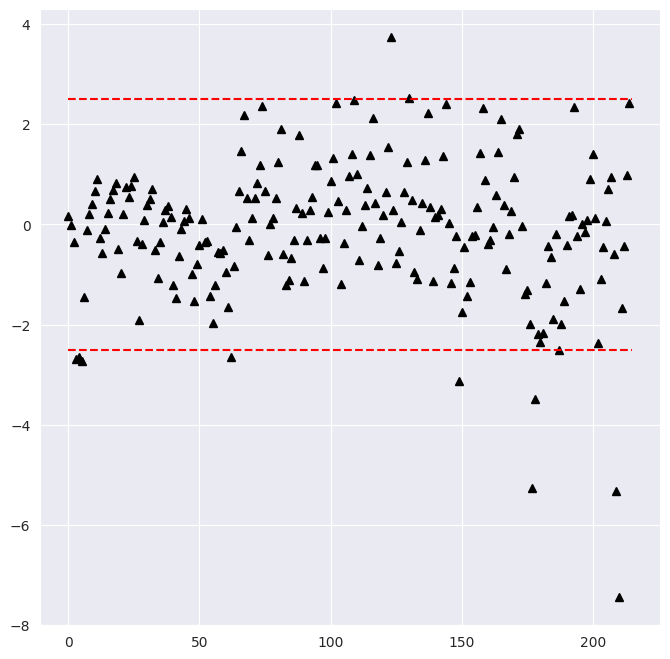

In [62]:
data = transformed_data['modified_zscore'].values
plot_modified_zscore(data, degree=2.5)

#### QQ-plot

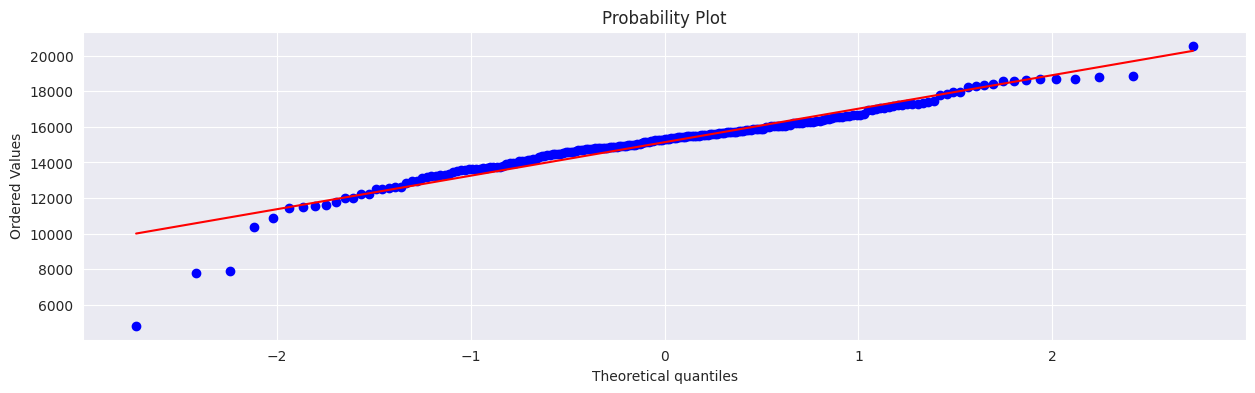

In [63]:
import scipy
import matplotlib.pyplot as plt
res = scipy.stats.probplot(tx.values.reshape(-1), plot=plt)

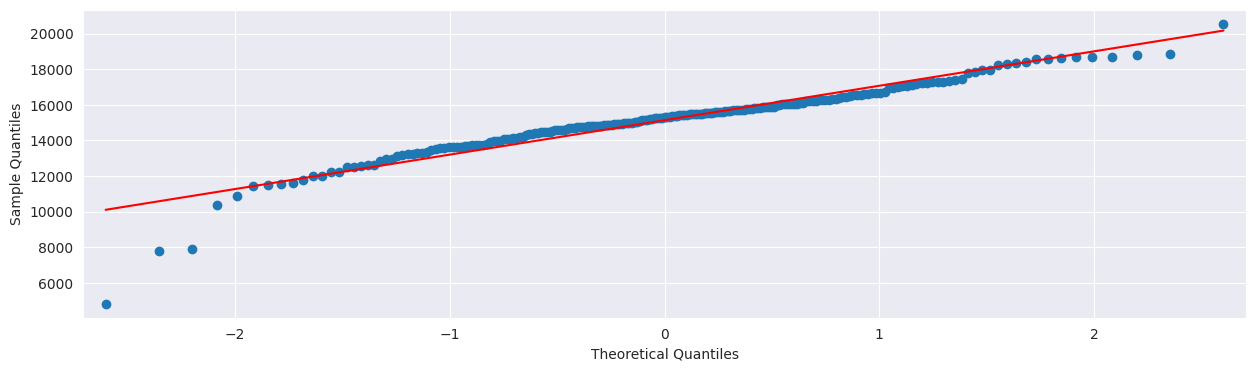

In [64]:
from statsmodels.graphics.gofplots import qqplot
qqplot(tx.values.reshape(-1), line='s')
plt.show()